In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

### loading dataset

In [2]:
data_set = pd.read_csv("SalaryData.csv")

### spilting the loaded data set into training data and testing data

In [3]:
# 30% data for testing and 70% for training,random state is 0 to get same results every time we run
x_train,x_test,y_train,y_test=train_test_split(data_set["YearsExperience"],data_set["Salary"],test_size=0.3,random_state=0)

### now x is for years of experience and y is for salary

In [4]:
print (y_train)
x_train

22    101302.0
5      56642.0
16     66029.0
8      64445.0
14     61111.0
23    113812.0
20     91738.0
1      46205.0
29    121872.0
6      60150.0
4      39891.0
18     81363.0
19     93940.0
9      57189.0
7      54445.0
25    105582.0
3      43525.0
0      39343.0
21     98273.0
15     67938.0
12     56957.0
Name: Salary, dtype: float64


22     7.9
5      2.9
16     5.1
8      3.2
14     4.5
23     8.2
20     6.8
1      1.3
29    10.5
6      3.0
4      2.2
18     5.9
19     6.0
9      3.7
7      3.2
25     9.0
3      2.0
0      1.1
21     7.1
15     4.9
12     4.0
Name: YearsExperience, dtype: float64

### formula for Linear Regression using Gradient Descent
y^ = b0 + b1*x

Mean Squared Error (MSE) Cost Function:
J(b0, b1) = (1/n) * Σ (y_pred - y)²

Gradient Descent Update Rules:
b0 = b0 - α * (2/n) * Σ (y_pred - y)
b1 = b1 - α * (2/n) * Σ (y_pred - y) * x

where α is the learning rate

# gradient descent function for our model

In [5]:
def gradient_descent_linear_regression(x, y, learning_rate=0.01, iterations=1000):
    # converting pandas series to numpy arrays and reshaping them to 1D arrays
    x = np.array(x).reshape(-1)
    y = np.array(y).reshape(-1)
    
    # normalize features for better convergence
    x_mean = np.mean(x)
    x_std = np.std(x)
    y_mean = np.mean(y)
    y_std = np.std(y)
    
    x_norm = (x - x_mean) / x_std
    y_norm = (y - y_mean) / y_std
    
    # initialize parameters
    b0 = 0
    b1 = 0
    n = len(x)
    
    # gradient descent iterations
    for i in range(iterations):
        # compute predictions
        y_pred = b0 + b1 * x_norm
        
        # compute error
        error = y_pred - y_norm
        
        # compute gradients
        gradient_b0 = (2/n) * np.sum(error)
        gradient_b1 = (2/n) * np.sum(error * x_norm)
        
        # update parameters
        b0 = b0 - learning_rate * gradient_b0
        b1 = b1 - learning_rate * gradient_b1
    
    # convert back to original scale
    b1_original = (y_std * b1) / x_std
    b0_original = y_mean + y_std * b0 - b1_original * x_mean
    
    return b0_original, b1_original

### Calculating b0 and b1 using gradient descent

In [6]:
b0, b1 = gradient_descent_linear_regression(x_train, y_train, learning_rate=0.1, iterations=1000)
# printing the calculated b0 and b1
b0 , b1

(np.float64(26777.391341197646), np.float64(9360.261286193654))

### function for prediction 

In [7]:
# Make predictions using the formula: y^ = b0 + b1*x
def predict(x, b0, b1):
    x = np.array(x).reshape(-1)
    return b0 + b1 * x

### prediction on test data (x_test)

In [8]:
y_hat = predict(x_test, b0, b1)
y_hat

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

### plotting scatter plot and regression line (gradient descent model)

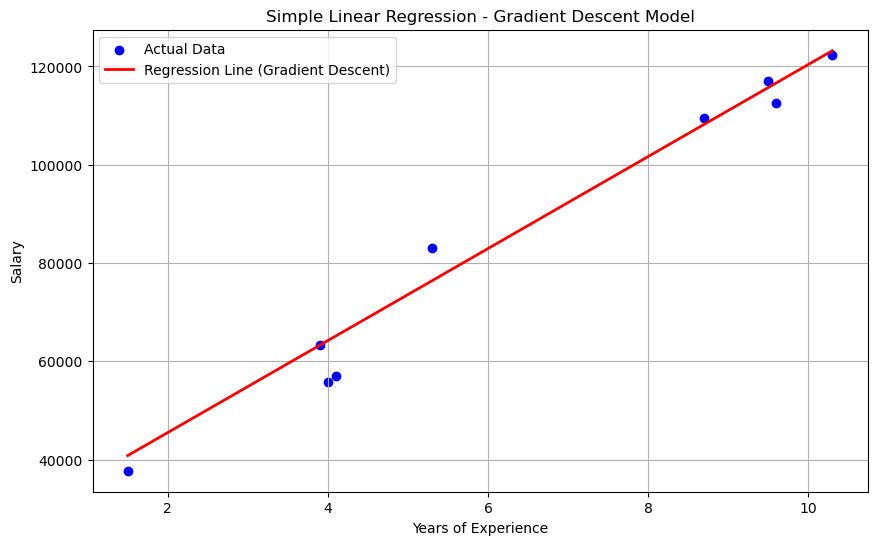

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='blue', label='Actual Data')
x_line = np.linspace(x_test.min(), x_test.max(), 100)
y_line = predict(x_line, b0, b1)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line (Gradient Descent)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Simple Linear Regression - Gradient Descent Model')
plt.legend()
plt.grid(True)
plt.savefig('gradient_descent_regression.png', dpi=150)
plt.show()

# sklearn model

In [10]:
# training sklearn LinearRegression model
model = LinearRegression()
model.fit(x_train.values.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# get the b1 (weight/slope) and b0 (intercept/bias) from sklearn
b1_sklearn = model.coef_[0]   # weight/slope
b0_sklearn = model.intercept_ # bias/intercept
print(b1_sklearn)
print(b0_sklearn)

9360.261286193654
26777.391341197632


In [12]:
# prediction using sklearn model
y_hat_sklearn = model.predict(x_test.values.reshape(-1, 1))
y_hat_sklearn

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

### plotting scatter plot and regression line (sklearn model)

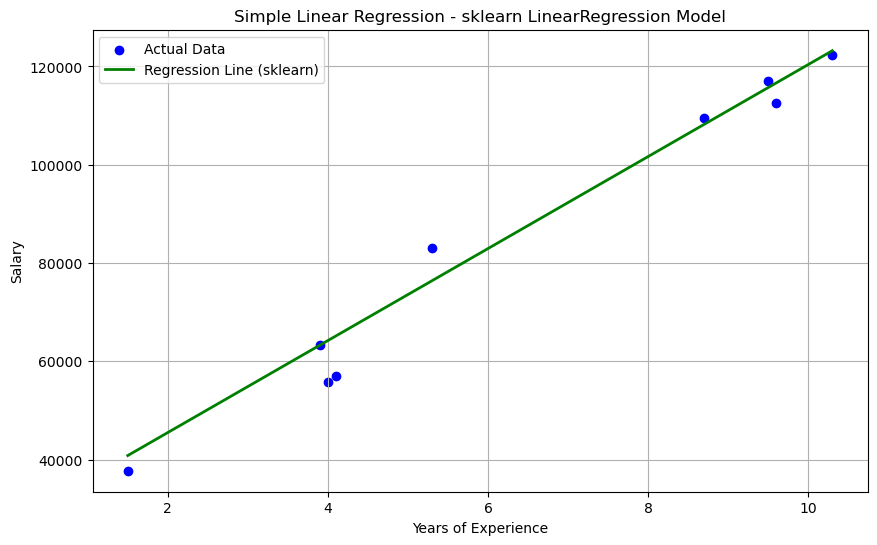

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='blue', label='Actual Data')
y_line_sklearn = model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line_sklearn, color='green', linewidth=2, label='Regression Line (sklearn)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Simple Linear Regression - sklearn LinearRegression Model')
plt.legend()
plt.grid(True)
plt.savefig('sklearn_regression.png', dpi=150)
plt.show()

### coefficients comparison

In [14]:
print(f"Gradient Descent Model: b0 = {b0}, b1 = {b1}")
print(f"sklearn Model: b0 = {b0_sklearn}, b1 = {b1_sklearn}")

Gradient Descent Model: b0 = 26777.391341197646, b1 = 9360.261286193654
sklearn Model: b0 = 26777.391341197632, b1 = 9360.261286193654


### evaluation metrics formulas
Mean Absolute Error (MAE): MAE = (1/n) * Σ |yi - y_pred_i|

R² Score: R² = 1 - ( Σ (yi - y_pred_i)² / Σ (yi - y_mean)² )

Root Mean Square Error (RMSE): RMSE = sqrt((1/n) * Σ (yi - y_pred_i)²)

In [15]:
# function to calculate Mean Absolute Error
def MAE(y_original, y_predicted):
    n = len(y_original)
    mean_abs_err = np.sum(np.abs(y_original - y_predicted)) / n
    return mean_abs_err

In [16]:
# function to calculate R² Score
def r2(y_true, y_pred):
    y_mean = np.mean(y_true)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_mean) ** 2))
    return r2

In [17]:
# function to calculate Root Mean Square Error
def RMSE(y_true, y_pred):
    n = len(y_true)
    rmse = np.sqrt(np.sum((y_true - y_pred) ** 2) / n)
    return rmse

In [18]:
# calculate evaluation metrics for gradient descent implementation on test data
mae_manual = MAE(y_test.values, y_hat)
r2_manual = r2(y_test.values, y_hat)
rmse_manual = RMSE(y_test.values, y_hat)

print(f"MAE (Gradient Descent):  {mae_manual}")
print(f"R² Score (Gradient Descent): {r2_manual}")
print(f"RMSE (Gradient Descent): {rmse_manual}")

MAE (Gradient Descent):  3737.417861878905
R² Score (Gradient Descent): 0.974099340721351
RMSE (Gradient Descent): 4834.260936361737


# evaluation metrics using sklearn

In [19]:
# calculate evaluation metrics for sklearn implementation on test data
mae_sklearn = metrics.mean_absolute_error(y_test.values, y_hat_sklearn)
r2_sklearn = metrics.r2_score(y_test.values, y_hat_sklearn)
rmse_sklearn = np.sqrt(metrics.mean_squared_error(y_test.values, y_hat_sklearn))

print(f"MAE (sklearn):  {mae_sklearn}")
print(f"R² Score (sklearn): {r2_sklearn}")
print(f"RMSE (sklearn): {rmse_sklearn}")

MAE (sklearn):  3737.4178618788987
R² Score (sklearn): 0.9740993407213511
RMSE (sklearn): 4834.260936361728
